In [37]:
# Import libraries
import numpy as np
import pandas as pd
import rasterio as rio
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import os

**Lectura y visualización de los datos vectoriales**

In [12]:
# Read vector data
vector_lago = gpd.read_file('vector_lago_22_02_2017.shp').to_crs(epsg=4326)
vector_ptosSamp = gpd.read_file('puntos_muestreo32620.shp').to_crs(epsg=4326)

<Axes: >

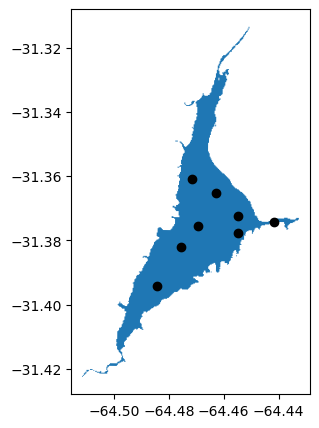

In [19]:
# Visualize vector data
fig, ax = plt.subplots(figsize=(7, 5))
vector_lago.plot(ax=ax)
vector_ptosSamp.plot(ax=ax, color = 'black')

## Lectura y procesamiento imágenes L8

**Creación del stack B1-B7**

In [ ]:
# Get raster paths
## Define folder path
directory_path = 'L8'

## List all files in the directory
all_files = os.listdir(directory_path)

'''## Remove not .tif files
all_files_filt = []
for i in range(len(all_files)):
    if all_files[i][-4:] == '.TIF':
        all_files_filt.append(all_files[i])

## Print filter files list
print(all_files_filt)'''

['LC08_L2SP_229082_20170222_20200905_02_T1_SR_B1.TIF', 'LC08_L2SP_229082_20170222_20200905_02_T1_SR_B2.TIF', 'LC08_L2SP_229082_20170222_20200905_02_T1_SR_B3.TIF', 'LC08_L2SP_229082_20170222_20200905_02_T1_SR_B4.TIF', 'LC08_L2SP_229082_20170222_20200905_02_T1_SR_B5.TIF', 'LC08_L2SP_229082_20170222_20200905_02_T1_SR_B6.TIF', 'LC08_L2SP_229082_20170222_20200905_02_T1_SR_B7.TIF', 'LC08_L2SP_229082_20170222_20200905_02_T1_ST_TRAD.TIF', 'LC08_L2SP_229082_20170222_20200905_02_T1_ST_URAD.TIF']


In [77]:
# Define output file name
stack_file = "B1toB7_stack03.tif"

# Define a list for bands data
stack_data = []

# For loop for stacking
for f_path in all_files[:-4]:
    with rio.open(directory_path+'/'+f_path) as band:
        print(directory_path+'/'+f_path)
        print(band.read().mean())
        stack_data.append(band.read())

L8/LC08_L2SP_229082_20170222_20200905_02_T1_SR_B1.TIF
6017.83178146698
L8/LC08_L2SP_229082_20170222_20200905_02_T1_SR_B2.TIF
6201.85079647239
L8/LC08_L2SP_229082_20170222_20200905_02_T1_SR_B3.TIF
6955.746781732459
L8/LC08_L2SP_229082_20170222_20200905_02_T1_SR_B4.TIF
6739.424635495667
L8/LC08_L2SP_229082_20170222_20200905_02_T1_SR_B5.TIF
14616.637596253704
L8/LC08_L2SP_229082_20170222_20200905_02_T1_SR_B6.TIF
10578.924736818231
L8/LC08_L2SP_229082_20170222_20200905_02_T1_SR_B7.TIF
8159.673462961746


In [78]:
# -
stack_data_conc = np.concatenate(stack_data, axis=0)

# Conver DN data to reflectance accordig to L8 specifications
stack_data_ref = (0.0001*stack_data_conc)
stack_data_ref = np.where(stack_data_ref < 0, np.nan, stack_data_ref)
stack_data_ref = np.where(stack_data_ref > 1, np.nan, stack_data_ref)

(array([1.8608009e+07, 1.3341000e+04, 2.1040000e+04, 3.3002000e+04,
        5.2689000e+04, 9.1197000e+04, 2.4160700e+05, 1.9903293e+07,
        1.6096746e+07, 1.7083400e+06]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

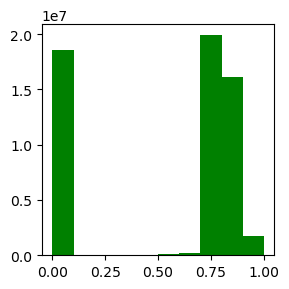

In [97]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.hist(stack_data_ref[0].flatten(), color="green")

In [83]:
stack_data_ref.shape[0]

7

In [84]:
# Get raster profile
with rio.open(directory_path+'/'+all_files[:-4][0]) as band: # Use band 1 for profile
    profile = band.profile

# Update metadate profile for 7 bands
profile.update(count=stack_data_ref.shape[0])

# Write the new 7 bands raster file
with rio.open(stack_file, "w", **profile) as dst:
    dst.write(stack_data_ref)

c:\Users\win10\anaconda3\Lib\site-packages\numpy\_core\_asarray.py:127: RuntimeWarning: invalid value encountered in cast
  arr = array(a, dtype=dtype, order=order, copy=None, subok=subok)


**Enmascaramiento lago por MNDWI**

In [86]:
# Open L8 stack
tif_path = 'B1toB7_stack03.tif' # dn image
tif = rio.open(tif_path)

In [87]:
# Open and extract bands dara from image and store in a 3d numpy array
listBands_ref = []

with rio.open(tif_path) as src:

  profile = src.profile.copy()

  for b in range(1, tif.read().shape[0]+1):
      listBands_ref.append(src.read(b))

arrayBands_ref = np.array(listBands_ref)

In [95]:
arrayBands_ref[0].mean(), arrayBands_ref[1].mean(), arrayBands_ref[6].mean()

(np.float64(1.2781998425425977e-05),
 np.float64(2.645537305683561e-05),
 np.float64(0.0001791497989837336))

(array([5.9457861e+07, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 7.6000000e+02]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

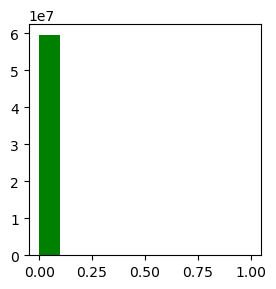

In [96]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.hist(arrayBands_ref[0].flatten(), color="green")

In [98]:
## MNDWI

# Extract red and nir bands
green_ref = arrayBands_ref[2]
swir_ref = arrayBands_ref[6]

# compute ndwi and concatenate to the original 3d array
mndwi = (green_ref-swir_ref)/(green_ref+swir_ref)
arrayBands_ref = np.concatenate((arrayBands_ref, mndwi[np.newaxis, :, :]), axis=0)

C:\Users\win10\AppData\Local\Temp\ipykernel_111260\491249420.py:8: RuntimeWarning: invalid value encountered in divide
  mndwi = (green_ref-swir_ref)/(green_ref+swir_ref)


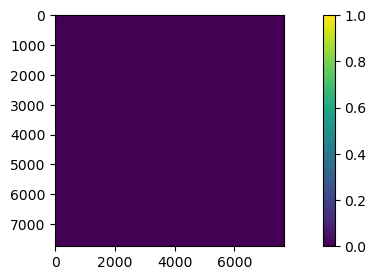

In [101]:
fig, ax = plt.subplots(figsize=(10, 3))

im = ax.imshow(arrayBands_ref[4], vmin=0, vmax=1) # Sets the colorbar max value to 100
fig.colorbar(im)